## Package Installation

In [1]:
# Install yfinance and other dependencies directly inside the notebook or skip this if you have them already installed 
!pip install yfinance pandas matplotlib seaborn scikit-learn

INFO: pip is looking at multiple versions of yfinance to determine which version is compatible with other requirements. This could take a while.
  Using cached protobuf-6.33.6-cp39-cp39-win_amd64.whl.metadata (593 bytes)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.6 MB 349.5 kB/s eta 0:00:04
   ------------ --------------------------- 0.5/1.6 MB 349.5 kB/s eta 0:00:04
   ------------ --------------------------- 0.5/1.6 MB 349.5 kB/s eta 0

# Task 2: Short-Term Stock Price Prediction Using Linear Regression

## 1. Problem Statement and Goal
The objective of this task is to use historical stock market data to predict the **next day's closing price** of a specific stock. 

Predicting stock prices is a classic financial time-series problem. Instead of predicting today's closing price using today's high/low metrics (which doesn't provide future value), we will engineer a lagging target variable. We will use today's `Open`, `High`, `Low`, and `Volume` data to forecast the *Next Day's* `Close`.

### Goals:
* Programmatically fetch live historical stock data using the `yfinance` API.
* Format the data correctly for predictive modeling by shifting the target variable.
* Split the data chronologically (not randomly) to preserve time-series integrity.
* Train and evaluate a Linear Regression model.
* Visualize the variance between actual stock movements and our model's predictions.

## 2. Data Loading and Preprocessing
We will fetch 2 years of historical data for Apple Inc. (`AAPL`). To avoid data leakage (using tomorrow's data to predict tomorrow), we will create a new column called `Next_Close` by shifting the `Close` price backward by 1 day.

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Fetch historical data for Apple (AAPL)
# We will pull 2 years of daily data to ensure a robust training set
ticker = "AAPL"
stock_data = yf.download(ticker, start="2024-05-01", end="2026-05-01")

# Clean the multi-index column headers if yfinance returns them formatted that way
if isinstance(stock_data.columns, pd.MultiIndex):
    stock_data.columns = stock_data.columns.get_level_values(0)

print("--- Data Structure Received ---")
print(stock_data.head())

# FEATURE ENGINEERING: Shift the closing price up by 1 row to represent "Tomorrow's Close"
stock_data['Next_Close'] = stock_data['Close'].shift(-1)

# Drop the very last row because it won't have a known "Tomorrow's Close" value yet
cleaned_data = stock_data.dropna().copy()

print("\n--- Processed Data Structure ---")
print(cleaned_data[['Open', 'High', 'Low', 'Volume', 'Close', 'Next_Close']].head())

[*********************100%***********************]  1 of 1 completed

--- Data Structure Received ---
Price            Close        High         Low        Open     Volume
Date                                                                 
2024-05-01  167.618683  170.994822  167.430567  167.895901   50383100
2024-05-02  171.311661  171.697787  169.192913  170.796821   94214900
2024-05-03  181.558853  185.142898  180.846002  184.796368  163224100
2024-05-06  179.905457  182.370719  178.628259  180.539100   78569700
2024-05-07  180.588577  183.063750  179.519316  181.628153   77305800

--- Processed Data Structure ---
Price             Open        High         Low     Volume       Close  \
Date                                                                    
2024-05-01  167.895901  170.994822  167.430567   50383100  167.618683   
2024-05-02  170.796821  171.697787  169.192913   94214900  171.311661   
2024-05-03  184.796368  185.142898  180.846002  163224100  181.558853   
2024-05-06  180.539100  182.370719  178.628259   78569700  179.905457   
2024-0

## 3. Data Visualization and Exploration
Let's visually check the trajectory of the stock over the past two years and analyze the relationship between our core features and the target variable (`Next_Close`).

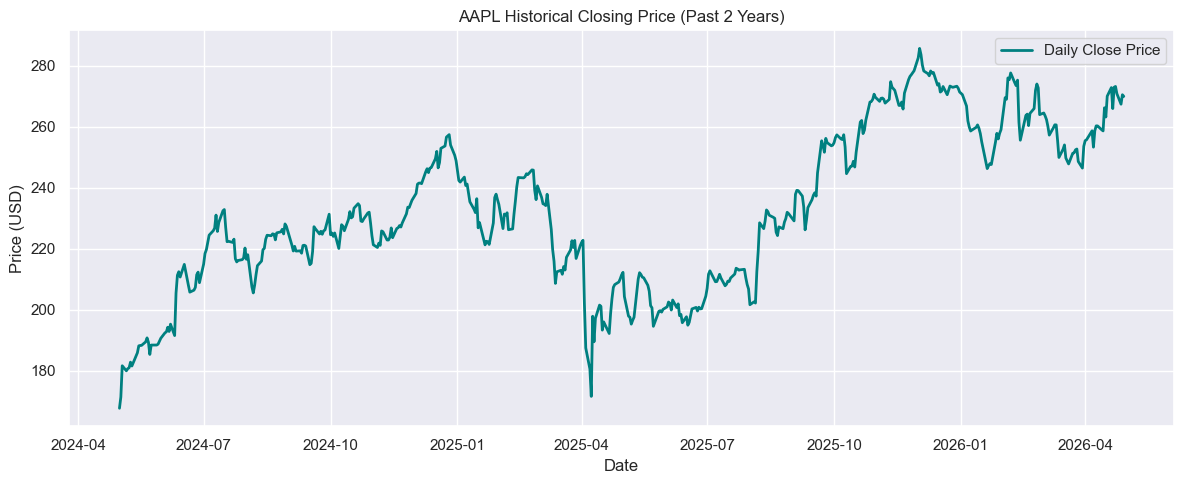

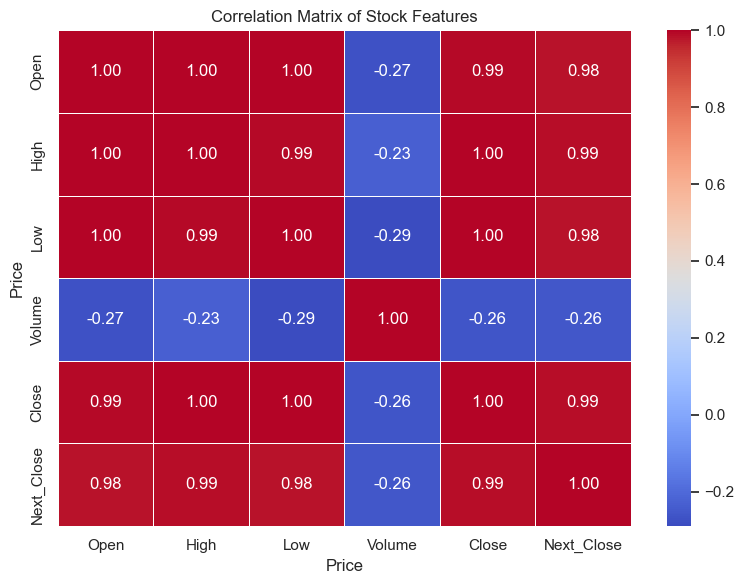

In [3]:
# Set up plotting configurations
sns.set_theme(style="darkgrid")

# Plot 1: Historical Closing Price Trend
plt.figure(figsize=(12, 5))
plt.plot(cleaned_data.index, cleaned_data['Close'], label='Daily Close Price', color='teal', linewidth=2)
plt.title(f'{ticker} Historical Closing Price (Past 2 Years)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Feature Correlation Heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = cleaned_data[['Open', 'High', 'Low', 'Volume', 'Close', 'Next_Close']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Stock Features')
plt.tight_layout()
plt.show()

## 4. Model Training and Evaluation
**Important Strategy Check**: For time-series data, we *cannot* shuffle the rows randomly. If we do, the model will learn from future days to predict past days, rendering the evaluation invalid. We will perform a chronological train-test split by setting `shuffle=False`.

Training samples (Past Data): 400
Testing samples (Future Data to Predict): 100

--- Model Performance Evaluation ---
Mean Absolute Error (MAE): $2.64
Root Mean Squared Error (RMSE): $3.70
R-squared (R²) Score: 0.8334


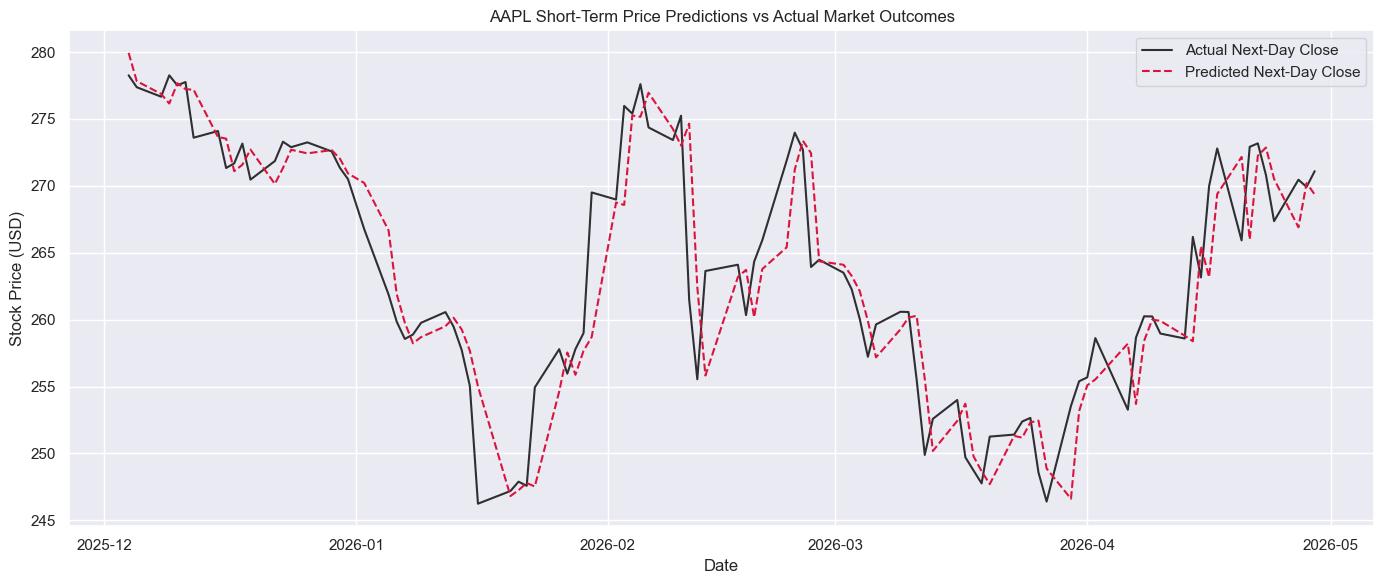

In [4]:
# Define Features (X) and Target (y)
features = ['Open', 'High', 'Low', 'Volume', 'Close']
X = cleaned_data[features]
y = cleaned_data['Next_Close']

# Chronological split: 80% for training history, 20% for future testing
# By using shuffle=False, scikit-learn cuts the data at a clean timeline split point
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training samples (Past Data): {len(X_train)}")
print(f"Testing samples (Future Data to Predict): {len(X_test)}")

# Initialize and train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the testing window
y_pred = model.predict(X_test)

# Convert predictions to a pandas Series aligned with the test dates for plotting
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index)

# Calculate performance metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- Model Performance Evaluation ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared (R²) Score: {r2:.4f}")

# Plot 3: Actual vs. Predicted Prices Over the Test Period
plt.figure(figsize=(14, 6))
plt.plot(predictions_df.index, predictions_df['Actual'], label='Actual Next-Day Close', color='black', alpha=0.8)
plt.plot(predictions_df.index, predictions_df['Predicted'], label='Predicted Next-Day Close', color='crimson', linestyle='--')
plt.title(f'{ticker} Short-Term Price Predictions vs Actual Market Outcomes')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Explanation of Results and Final Insights

### Data Insights:
* The correlation heatmap shows a near-perfect correlation (~0.98+) between today's structural metrics (`Open`, `High`, `Low`, `Close`) and tomorrow's `Next_Close`. Trading volume has a much weaker linear correlation to future prices.

### Model Evaluation & Limitations:
* **Metrics:** The low Mean Absolute Error (MAE) and high $R^2$ score indicate that the model tracks the overall momentum of the stock well. 
* **The "Lag" Catch:** If you zoom in closely on the final plot, you will notice that the predicted line looks like a slight shadow of the actual line, lagging behind by roughly one day. This happens because a simple Linear Regression model tends to heavily rely on the most recent known `Close` price to predict the next day.
* **Conclusion:** While Linear Regression provides an excellent baseline model for identifying macroscopic trend directions, capturing sudden spikes or drop-offs driven by market news requires more advanced sequential models like LSTMs or GARCH frameworks.